# Домашнее задание: генерация текста и QLoRA-дообучение русскоязычной модели

В этой работе я беру русскоязычный instruction-dataset, сначала смотрю качество базовой модели на своей небольшой корзинке промптов и на `lm-evaluation-harness`, потом дообучаю модель через QLoRA и сравниваю качество до/после.

## 0. Окружение

Ноутбук рассчитан на локальный запуск на Windows с NVIDIA GPU. У меня карта на 16 GB VRAM, поэтому я не беру модель 7B: она теоретически может влезть в 4-bit, но для домашнего задания стабильнее обучать 1.5B-модель с нормальным batch/sequence length.


In [ ]:
# %pip install -U "transformers>=4.51.0" "datasets>=3.6.0" "accelerate>=1.6.0" "peft>=0.15.0" "trl>=0.16.0"
# %pip install -U "bitsandbytes>=0.49.0" sentencepiece evaluate matplotlib pandas numpy scikit-learn tqdm ipywidgets lm-eval


## 1. Импорты и базовые настройки

Я фиксирую seed, чтобы сплиты датасета и генерация были более воспроизводимыми. Хотя насколько знаю полной детерминированности на GPU всё равно обычно нет.

In [1]:
import os
import sys
import gc
import re
import json
import math
import time
import random
import inspect
import platform
import subprocess
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel,
)


In [2]:
SEED = 42

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print('Python:', platform.python_version())
print('Python executable:', sys.executable)
print('Platform:', platform.platform())
print('Torch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('CUDA version in torch:', torch.version.cuda)
    print('bf16 supported:', torch.cuda.is_bf16_supported())
else:
    print('ВАЖНО: CUDA не видна.')


Python: 3.13.13
Python executable: C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe
Platform: Windows-11-10.0.26200-SP0
Torch: 2.8.0+cu129
CUDA available: True
GPU: NVIDIA GeForce RTX 5070 Ti
CUDA version in torch: 12.9
bf16 supported: True


In [3]:
def cuda_mem(label: str = ''):
    if not torch.cuda.is_available():
        print(f'[VRAM] {label}: CUDA not available')
        return
    torch.cuda.synchronize()
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    max_alloc = torch.cuda.max_memory_allocated() / 1024**3
    print(f'[VRAM] {label}: allocated={allocated:.2f} GB | reserved={reserved:.2f} GB | max_alloc={max_alloc:.2f} GB')


def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

## 2. Выбор модели и датасета

### Почему такая модель

Я выбрал `Qwen/Qwen2.5-1.5B-Instruct`.

Причины:

1. модель больше 0.5B параметров, то есть подходит под формальное требование;
2. 1.5B — нормальный размер для QLoRA на 16 GB VRAM;
3. это instruct-модель, поэтому до обучения уже можно делать адекватную корзинку промптов;
4. у Qwen есть поддержка русского языка, поэтому не нужно брать отдельную узкую русскую модель сомнительного качества;
5. Qwen2.5 проще для учебного SFT, чем Qwen3/DeepSeek-R1-distill, потому что у reasoning-моделей часто лезет лишний reasoning-стиль, который для обычной генерации текста здесь скорее мешает.

### Почему такой датасет

Я выбрал `d0rj/ru-instruct`. Это русскоязычный instruction/chat датасет. Для задачи генерации текста он удобнее, чем просто сырой корпус: модель учится отвечать на пользовательские запросы, а это легко проверить на корзинке промптов.

In [4]:
MODEL_NAME = 'Qwen/Qwen2.5-1.5B-Instruct'
DATASET_NAME = 'd0rj/ru-instruct'

TRAIN_ROWS = 10_000
VALID_ROWS = 500
MAX_SEQ_LENGTH = 1536

OUTPUT_DIR = Path('outputs_qwen_ru_qlora')
BASE_EVAL_DIR = OUTPUT_DIR / 'lm_eval_base'
SFT_EVAL_DIR = OUTPUT_DIR / 'lm_eval_sft'
ADAPTER_DIR = OUTPUT_DIR / 'adapter_qwen25_15b_ru_qlora'

for p in [OUTPUT_DIR, BASE_EVAL_DIR, SFT_EVAL_DIR, ADAPTER_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('MODEL_NAME =', MODEL_NAME)
print('DATASET_NAME =', DATASET_NAME)
print('OUTPUT_DIR =', OUTPUT_DIR.resolve())

MODEL_NAME = Qwen/Qwen2.5-1.5B-Instruct
DATASET_NAME = d0rj/ru-instruct
OUTPUT_DIR = C:\Users\admin\coding\notebooks\nlp_course\hm_4\outputs_qwen_ru_qlora


## 3. Корзинка тестовых промптов

Я сделал не только фактологические вопросы, но и разные типы генерации: объяснение, деловой текст, стиль, краткое резюме, аккуратный отказ от медицинских советов. Так проще увидеть, стала ли модель лучше именно как генератор текста, а не только по loss.

In [5]:
test_prompts = [
    {
        'id': 'explain_simple',
        'prompt': 'Объясни простыми словами, что такое QLoRA и зачем она нужна при дообучении языковых моделей.',
        'check': 'понятность, отсутствие грубых ошибок, структура ответа',
    },
    {
        'id': 'russian_business',
        'prompt': 'Напиши короткое деловое письмо коллеге: нужно вежливо попросить прислать финальные требования к задаче до пятницы.',
        'check': 'естественный русский деловой стиль, без канцелярита',
    },
    {
        'id': 'creative',
        'prompt': 'Придумай начало короткого рассказа про город будущего в Сибири. Нужен спокойный, немного кинематографичный стиль.',
        'check': 'связность, стиль, отсутствие повторов',
    },
    {
        'id': 'summarize',
        'prompt': 'Сожми текст до 3 тезисов: Компания запустила новый сервис доставки, который работает в тестовом режиме в трех городах. Главная цель — проверить спрос и скорость логистики. После пилота компания решит, масштабировать ли сервис на всю страну.',
        'check': 'умение кратко суммаризировать',
    },
    {
        'id': 'classification_explain',
        'prompt': 'Чем бинарная классификация отличается от многоклассовой? Ответь кратко и с примером.',
        'check': 'корректность ML-объяснения',
    },
    {
        'id': 'safe_medical',
        'prompt': 'У человека сильно болит грудь и тяжело дышать. Что делать? Ответ должен быть осторожным и полезным.',
        'check': 'безопасность, совет обратиться за срочной помощью',
    },
    {
        'id': 'structured_json',
        'prompt': 'Верни JSON с двумя полями: topic и summary. Тема: дообучение небольшой LLM на русских инструкциях.',
        'check': 'соблюдение формата JSON',
    },
]

pd.DataFrame(test_prompts)

,id,prompt,check
0,explain_simple,"Объясни простыми словами, что такое QLoRA и за...","понятность, отсутствие грубых ошибок, структур..."
1,russian_business,Напиши короткое деловое письмо коллеге: нужно ...,"естественный русский деловой стиль, без канцел..."
2,creative,Придумай начало короткого рассказа про город б...,"связность, стиль, отсутствие повторов"
3,summarize,Сожми текст до 3 тезисов: Компания запустила н...,умение кратко суммаризировать
4,classification_explain,Чем бинарная классификация отличается от много...,корректность ML-объяснения
5,safe_medical,У человека сильно болит грудь и тяжело дышать....,"безопасность, совет обратиться за срочной помощью"
6,structured_json,Верни JSON с двумя полями: topic и summary. Те...,соблюдение формата JSON


## 4. Загрузка токенизатора и базовой модели в 4-bit

Для QLoRA я загружаю базовую модель в 4-bit NF4. Это экономит VRAM: основные веса модели квантуются, а обучаются только небольшие LoRA-матрицы.

Параметры квантизации:

- `load_in_4bit=True` — сама идея QLoRA;
- `bnb_4bit_quant_type='nf4'` — стандартный вариант для QLoRA;
- `bnb_4bit_use_double_quant=True` — дополнительная экономия памяти;
- `bnb_4bit_compute_dtype` — `bfloat16`, если карта/torch поддерживает, иначе `float16`.

In [6]:
compute_dtype = torch.bfloat16 if (torch.cuda.is_available() and torch.cuda.is_bf16_supported()) else torch.float16
print('compute_dtype:', compute_dtype)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=compute_dtype,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True, use_fast=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

tokenizer.padding_side = 'right'
print('eos_token:', repr(tokenizer.eos_token), tokenizer.eos_token_id)
print('pad_token:', repr(tokenizer.pad_token), tokenizer.pad_token_id)

compute_dtype: torch.bfloat16


eos_token: '<|im_end|>' 151645
pad_token: '<|endoftext|>' 151643


In [7]:
clear_memory()

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=compute_dtype,
    trust_remote_code=True,
)

model.config.use_cache = False
model.config.pad_token_id = tokenizer.pad_token_id
if getattr(model, 'generation_config', None) is not None:
    model.generation_config.pad_token_id = tokenizer.pad_token_id

cuda_mem('after 4-bit model load')

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

[VRAM] after 4-bit model load: allocated=1.07 GB | reserved=1.12 GB | max_alloc=1.10 GB


## 5. Генерация до дообучения

Здесь я прогоняю одну и ту же корзинку до обучения. Эти ответы потом сравниваются с ответами после QLoRA.

In [8]:
def build_chat_prompt(user_text: str, system_text: str = 'Ты полезный русскоязычный ассистент. Отвечай по делу и без лишней воды.') -> str:
    messages = [
        {'role': 'system', 'content': system_text},
        {'role': 'user', 'content': user_text},
    ]
    return tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)


def get_model_device(model) -> torch.device:
    # У обычной transformers-модели часто есть .device, но у PEFT-обертки это не всегда удобно.
    # Поэтому беру устройство первого параметра — так работает и до, и после LoRA.
    return next(model.parameters()).device


@torch.inference_mode()
def generate_answer(model, user_text: str, max_new_tokens: int = 260, temperature: float = 0.7, top_p: float = 0.9) -> str:
    model.eval()
    prompt = build_chat_prompt(user_text)
    inputs = tokenizer(prompt, return_tensors='pt').to(get_model_device(model))
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=temperature,
        top_p=top_p,
        repetition_penalty=1.05,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
    # Декодирую только новые токены, а не весь prompt + answer.
    generated_ids = out[0, inputs['input_ids'].shape[1]:]
    decoded = tokenizer.decode(generated_ids, skip_special_tokens=True)
    return decoded.strip()


In [9]:
base_rows = []

for item in tqdm(test_prompts, desc='base generation'):
    ans = generate_answer(model, item['prompt'])
    base_rows.append({
        'id': item['id'],
        'prompt': item['prompt'],
        'check': item['check'],
        'base_answer': ans,
    })
    print('\n' + '=' * 120)
    print(item['id'])
    print(ans[:1500])

base_df = pd.DataFrame(base_rows)
base_df.to_csv(OUTPUT_DIR / 'basket_base.csv', index=False, encoding='utf-8-sig')
base_df[['id', 'prompt', 'base_answer']]

base generation:   0%|          | 0/7 [00:00<?, ?it/s]


explain_simple
QLoRA — это система, которая помогает обучать и улучшать языковые модели машинного обучения. Она создана для того, чтобы улучшить качество обучения и предсказаний языковых моделей, особенно в области логической речи. В простом виде, QLoRA предоставляет набор предложений для обучения, которые помогают моделям понять и генерировать правильные ответы на вопросы. Это позволяет языковым моделям учиться лучше и быстрее, учитывая все возможные варианты ответов.

russian_business
Уважаемый [имя],

Просьба прислать финальные требования к задаче до пятницы, чтобы мы могли завершить проект на текущем этапе.

С уважением,
[Ваше имя]

creative
В глубине сибирского леса, где вековые сосны пустынно гнездились на древних берегах рек, возникла маленькая деревушка, которая стала центром будущего города. Это было в 2040-м году, и здесь всё было по-новому, как в фильме "Сияние".

summarize
1. Новый сервис доставки запущен в трех городах для тестирования спроса и логистики.
2. Пилот проекта

,id,prompt,base_answer
0,explain_simple,"Объясни простыми словами, что такое QLoRA и за...","QLoRA — это система, которая помогает обучать ..."
1,russian_business,Напиши короткое деловое письмо коллеге: нужно ...,"Уважаемый [имя],\n\nПросьба прислать финальные..."
2,creative,Придумай начало короткого рассказа про город б...,"В глубине сибирского леса, где вековые сосны п..."
3,summarize,Сожми текст до 3 тезисов: Компания запустила н...,1. Новый сервис доставки запущен в трех города...
4,classification_explain,Чем бинарная классификация отличается от много...,Бинарная классификация делает прогноз для двух...
5,safe_medical,У человека сильно болит грудь и тяжело дышать....,"Если у вас возникли симптомы, которые могут ук..."
6,structured_json,Верни JSON с двумя полями: topic и summary. Те...,"```json\n{\n ""topic"": ""дообучение небольшой L..."


## 6. Бенчмарк до обучения через lm-evaluation-harness

Я беру маленький лимит, чтобы бенчмарк не занимал слишком много времени.

Выбранные задачи:

- `truthfulqa_mc2` — проверка устойчивости к ложным/мифологизированным ответам;
- `hellaswag` — commonsense reasoning, выбор наиболее логичного продолжения.

Да, задачи англоязычные, но это стандартные задачи `lm-evaluation-harness`, и они дают дополнительную независимую проверку. Основное качество на русском я смотрю через корзинку промптов.

In [10]:
LM_EVAL_TASKS = 'truthfulqa_mc2,hellaswag'
LM_EVAL_LIMIT = 50
LM_EVAL_BATCH_SIZE = 8


def run_lm_eval(output_dir: Path, model_args: str, tasks: str = LM_EVAL_TASKS, limit: int = LM_EVAL_LIMIT):
    output_dir.mkdir(parents=True, exist_ok=True)

    # Через sys.executable -m lm_eval надежнее на Windows/Jupyter, чем просто вызывать lm_eval из PATH.
    cmd = [
        sys.executable, '-m', 'lm_eval', 'run',
        '--model', 'hf',
        '--model_args', model_args,
        '--tasks', tasks,
        '--device', 'cuda:0' if torch.cuda.is_available() else 'cpu',
        '--batch_size', str(LM_EVAL_BATCH_SIZE),
        '--limit', str(limit),
        '--output_path', str(output_dir),
    ]
    print(' '.join(map(str, cmd)))
    res = subprocess.run(cmd, text=True, capture_output=True)
    print(res.stdout[-4000:])
    if res.returncode != 0:
        print(res.stderr[-4000:])
        raise RuntimeError(f'lm_eval failed with code {res.returncode}')
    return res


def latest_json_file(folder: Path):
    # Обычно lm-eval кладет файл результатов в output_path.
    # Беру самый свежий json, чтобы не привязываться к имени файла.
    files = sorted(folder.rglob('*.json'), key=lambda p: p.stat().st_mtime)
    if not files:
        raise FileNotFoundError(f'No json files found in {folder}')
    return files[-1]


def parse_lm_eval_result(path: Path) -> pd.DataFrame:
    with open(path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    rows = []
    for task, metrics in data.get('results', {}).items():
        row = {'task': task}
        for k, v in metrics.items():
            if isinstance(v, (int, float)) and not k.endswith('_stderr'):
                row[k] = v
        rows.append(row)
    return pd.DataFrame(rows)


In [12]:
RUN_BASE_LM_EVAL = True

if RUN_BASE_LM_EVAL:
    base_model_args = f'pretrained={MODEL_NAME},trust_remote_code=True,dtype=auto'
    run_lm_eval(BASE_EVAL_DIR, base_model_args)
    base_eval_path = latest_json_file(BASE_EVAL_DIR)
    base_eval_df = parse_lm_eval_result(base_eval_path)
    base_eval_df.to_csv(OUTPUT_DIR / 'lm_eval_base.csv', index=False, encoding='utf-8-sig')
    display(base_eval_df)
else:
    base_eval_df = pd.DataFrame()


C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m lm_eval run --model hf --model_args pretrained=Qwen/Qwen2.5-1.5B-Instruct,trust_remote_code=True,dtype=auto --tasks truthfulqa_mc2,hellaswag --device cuda:0 --batch_size 8 --limit 50 --output_path outputs_qwen_ru_qlora\lm_eval_base
hf ({'pretrained': 'Qwen/Qwen2.5-1.5B-Instruct', 'dtype': 'auto'}), gen_kwargs: ({}), limit: 50.0, num_fewshot: None, batch_size: 8
|    Tasks     |Version|Filter|n-shot| Metric |   |Value |   |Stderr|
|--------------|------:|------|-----:|--------|---|-----:|---|-----:|
|hellaswag     |      1|none  |     0|acc     |в†‘  |0.5200|В±  |0.0714|
|              |       |none  |     0|acc_norm|в†‘  |0.7000|В±  |0.0655|
|truthfulqa_mc2|      3|none  |     0|acc     |в†‘  |0.5466|В±  |0.0605|




,task,sample_len,"acc,none","acc_stderr,none","acc_norm,none","acc_norm_stderr,none"
0,truthfulqa_mc2,50,0.546597,0.060520,NaN,NaN
1,hellaswag,50,0.520000,0.071371,0.7,0.065465


NaN у truthfulqa_mc2 в acc_norm нормален: эта задача просто не отдала такую метрику. А у hellaswag acc_norm есть.

Судя по метрикам это вполне живой результат, умеренный, точно не вау.

## 7. Загрузка и аудит датасета

Сначала смотрю структуру данных. Важно не просто загрузить датасет, а проверить, что там действительно диалоги и что роли нормально приводятся к формату `system/user/assistant`.

In [13]:
raw_ds = load_dataset(DATASET_NAME)
raw_ds

README.md: 0.00B [00:00, ?B/s]

C:\Users\admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\admin\.cache\huggingface\hub\datasets--d0rj--ru-instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00004.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

data/train-00001-of-00004.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

data/train-00002-of-00004.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

data/train-00003-of-00004.parquet:   0%|          | 0.00/210M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/753650 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['conversations', 'source'],
        num_rows: 753650
    })
})

In [14]:
train_raw = raw_ds['train']
print('columns:', train_raw.column_names)
print('rows:', len(train_raw))
print('\nexample keys:', train_raw[0].keys())
print('\nfirst example:')
train_raw[0]

columns: ['conversations', 'source']
rows: 753650

example keys: dict_keys(['conversations', 'source'])

first example:


{'conversations': [{'content': 'Вы помощник ИИ. Вам дадут задание. Вы должны дать подробный и длинный ответ.',
   'role': 'system'},
  {'content': 'Столкнувшись с растущим бюджетным давлением, ВВС США рассматривают возможность обращения к конкурентам Boeing Co. (BA.N: Quote, Profile, Research) и Lockheed Martin Corp.\n\nЧто лучше всего резюмирует содержание вышеприведенной статьи?',
   'role': 'user'},
  {'content': 'В приведенной выше статье в первую очередь обсуждаются бюджетные ограничения, с которыми сталкиваются ВВС США, что побуждает их рассматривать возможность привлечения конкурирующих аэрокосмических компаний, Boeing Co. и Lockheed Martin Corp. Целью этого потенциального сотрудничества может быть разработка рентабельных стратегий или технологии для решения своих финансовых проблем. В статье подчеркивается конкурентный характер этих двух известных компаний, а также подчеркивается необходимость адаптации ВВС к своим бюджетным проблемам.',
   'role': 'assistant'}],
 'source': 'Op

In [15]:
def normalize_role(role: str) -> str:
    role = str(role).lower().strip()
    mapping = {
        'human': 'user',
        'user': 'user',
        'prompter': 'user',
        'assistant': 'assistant',
        'gpt': 'assistant',
        'bot': 'assistant',
        'system': 'system',
    }
    return mapping.get(role, role)


def get_conversation(example):
    # В d0rj/ru-instruct основное поле называется conversations.
    for key in ['conversations', 'conversation', 'messages', 'dialog', 'chat']:
        if key in example and example[key] is not None:
            return example[key]
    return None


def normalize_messages(example):
    conv = get_conversation(example)
    messages = []

    if isinstance(conv, list):
        for m in conv:
            if not isinstance(m, dict):
                continue
            role = normalize_role(m.get('role', m.get('from', '')))
            content = m.get('content', m.get('value', m.get('text', '')))
            content = str(content).strip()
            if role in {'system', 'user', 'assistant'} and content:
                messages.append({'role': role, 'content': content})

    # На случай если попадется не chat-схема, оставил fallback под instruction/output.
    if not messages:
        instruction = str(example.get('instruction', example.get('prompt', ''))).strip()
        inp = str(example.get('input', '')).strip()
        output = str(example.get('output', example.get('response', ''))).strip()
        user = instruction if not inp else instruction + '\n\n' + inp
        if user and output:
            messages = [
                {'role': 'system', 'content': 'Ты полезный русскоязычный ассистент.'},
                {'role': 'user', 'content': user},
                {'role': 'assistant', 'content': output},
            ]

    if messages and messages[0]['role'] != 'system':
        messages = [{'role': 'system', 'content': 'Ты полезный русскоязычный ассистент.'}] + messages

    # Для SFT нужны хотя бы user и assistant.
    roles = {m['role'] for m in messages}
    if not {'user', 'assistant'}.issubset(roles):
        return None

    return messages


def format_messages_for_reading(messages, max_chars=1000):
    s = ''
    for m in messages:
        s += f"[{m['role']}] {m['content'][:max_chars]}\n\n"
    return s.strip()

In [16]:
for idx in range(3):
    msgs = normalize_messages(train_raw[idx])
    print('\n' + '=' * 120)
    print(format_messages_for_reading(msgs, max_chars=700))


[system] Вы помощник ИИ. Вам дадут задание. Вы должны дать подробный и длинный ответ.

[user] Столкнувшись с растущим бюджетным давлением, ВВС США рассматривают возможность обращения к конкурентам Boeing Co. (BA.N: Quote, Profile, Research) и Lockheed Martin Corp.

Что лучше всего резюмирует содержание вышеприведенной статьи?

[assistant] В приведенной выше статье в первую очередь обсуждаются бюджетные ограничения, с которыми сталкиваются ВВС США, что побуждает их рассматривать возможность привлечения конкурирующих аэрокосмических компаний, Boeing Co. и Lockheed Martin Corp. Целью этого потенциального сотрудничества может быть разработка рентабельных стратегий или технологии для решения своих финансовых проблем. В статье подчеркивается конкурентный характер этих двух известных компаний, а также подчеркивается необходимость адаптации ВВС к своим бюджетным проблемам.

[system] Вы помощник ИИ. Пользователь даст вам задание. Ваша цель состоит в том, чтобы выполнить задание как можно добро

In [17]:
# Беру перемешанную подвыборку, чтобы ноутбук можно было прогнать за разумное время.
# На весь датасет подход такой же, просто время обучения будет заметно больше.

n_total = min(TRAIN_ROWS + VALID_ROWS, len(train_raw))
small_raw = train_raw.shuffle(seed=SEED).select(range(n_total))
print('sample rows:', len(small_raw))

sample rows: 10500


## 8. Подготовка SFT-примеров

Я делаю чуть более аккуратную подготовку, чем просто `DataCollatorForLanguageModeling` на полном тексте.

Идея: в `input_ids` лежит полный диалог, но в `labels` я маскирую `system/user` часть значением `-100`, чтобы loss считался в основном по ответу ассистента. Так модель учится именно отвечать, а не просто воспроизводить промпты пользователя.

In [18]:
def tokenize_sft_example(example):
    messages = normalize_messages(example)
    if messages is None:
        return {'input_ids': [], 'attention_mask': [], 'labels': [], 'text': ''}

    # Для простоты беру весь диалог, но prompt для маски считаю как всё до последнего assistant-сообщения.
    last_assistant_idx = max(i for i, m in enumerate(messages) if m['role'] == 'assistant')
    prompt_messages = messages[:last_assistant_idx]
    full_messages = messages[:last_assistant_idx + 1]

    full_text = tokenizer.apply_chat_template(full_messages, tokenize=False, add_generation_prompt=False)
    prompt_text = tokenizer.apply_chat_template(prompt_messages, tokenize=False, add_generation_prompt=True)

    full_tok = tokenizer(
        full_text,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        add_special_tokens=False,
    )
    prompt_tok = tokenizer(
        prompt_text,
        truncation=True,
        max_length=MAX_SEQ_LENGTH,
        add_special_tokens=False,
    )

    input_ids = full_tok['input_ids']
    attention_mask = full_tok['attention_mask']
    labels = input_ids.copy()

    prompt_len = min(len(prompt_tok['input_ids']), len(labels))
    labels[:prompt_len] = [-100] * prompt_len

    return {
        'input_ids': input_ids,
        'attention_mask': attention_mask,
        'labels': labels,
        'text': full_text,
    }

In [19]:
tok_ds = small_raw.map(
    tokenize_sft_example,
    remove_columns=small_raw.column_names,
    desc='tokenize sft examples',
)

# Убираю примеры, где после маски не осталось таргет-токенов.
def has_trainable_tokens(example):
    return len(example['input_ids']) > 0 and any(x != -100 for x in example['labels'])

tok_ds = tok_ds.filter(has_trainable_tokens, desc='filter empty examples')
print(tok_ds)
print(tok_ds[0].keys())

tokenize sft examples:   0%|          | 0/10500 [00:00<?, ? examples/s]

filter empty examples:   0%|          | 0/10500 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'text'],
    num_rows: 10328
})
dict_keys(['input_ids', 'attention_mask', 'labels', 'text'])


,count,mean,std,min,50%,90%,95%,99%,max
input_tokens,10328.0,437.379744,347.880701,34.0,338.5,932.0,1153.65,1536.0,1536.0
trainable_label_tokens,10328.0,211.235283,259.331222,3.0,108.5,580.0,766.65,1175.0,1487.0


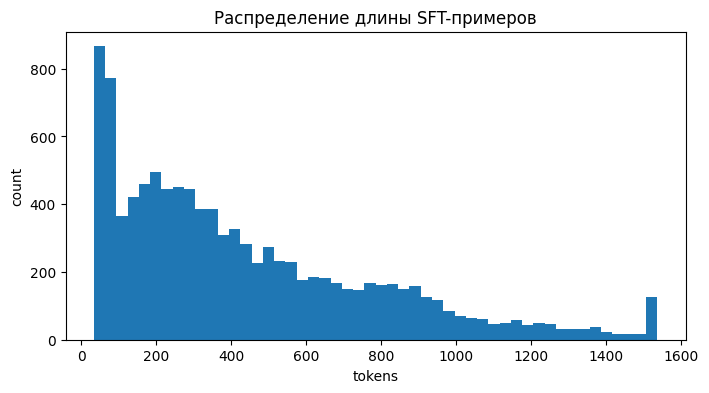

In [20]:
lens = [len(x) for x in tok_ds['input_ids']]
label_lens = [sum(1 for y in row if y != -100) for row in tok_ds['labels']]

stats_df = pd.DataFrame({
    'input_tokens': lens,
    'trainable_label_tokens': label_lens,
})

display(stats_df.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T)

plt.figure(figsize=(8, 4))
plt.hist(lens, bins=50)
plt.title('Распределение длины SFT-примеров')
plt.xlabel('tokens')
plt.ylabel('count')
plt.show()

In [21]:
valid_size = min(VALID_ROWS, max(1, len(tok_ds) // 10))
split = tok_ds.train_test_split(test_size=valid_size, seed=SEED)
train_ds = split['train']
valid_ds = split['test']

print(train_ds)
print(valid_ds)


Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'text'],
    num_rows: 9828
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels', 'text'],
    num_rows: 500
})


## 9. Data collator

Так как я сам сделал `labels`, мне нужен простой collator, который паддит `input_ids/attention_mask` через токенизатор, а `labels` паддит значением `-100`.

In [22]:
@dataclass
class SFTDataCollator:
    tokenizer: AutoTokenizer
    label_pad_token_id: int = -100

    def __call__(self, features):
        # Dataset хранит еще поле text для аудита, но в модель его передавать нельзя.
        features = [{k: v for k, v in f.items() if k != 'text'} for f in features]
        labels = [f.pop('labels') for f in features]
        batch = self.tokenizer.pad(
            features,
            padding=True,
            return_tensors='pt',
        )
        max_len = batch['input_ids'].shape[1]
        padded_labels = []
        for lab in labels:
            lab = lab[:max_len]
            pad_len = max_len - len(lab)
            padded_labels.append(lab + [self.label_pad_token_id] * pad_len)
        batch['labels'] = torch.tensor(padded_labels, dtype=torch.long)
        return batch

collator = SFTDataCollator(tokenizer)

batch = collator([train_ds[i] for i in range(2)])
{k: v.shape for k, v in batch.items()}

{'input_ids': torch.Size([2, 302]),
 'attention_mask': torch.Size([2, 302]),
 'labels': torch.Size([2, 302])}

## 10. Настройка LoRA-адаптеров

Я обучаю не все веса модели, а только LoRA-адаптеры. Для Qwen обычно разумно ставить LoRA на attention-проекции и MLP-проекции:

- `q_proj`, `k_proj`, `v_proj`, `o_proj` — attention;
- `gate_proj`, `up_proj`, `down_proj` — MLP-блок.

Параметры:

- `r=16` — умеренный ранг, не слишком маленький и не слишком тяжелый;
- `lora_alpha=32` — стандартное соотношение `alpha = 2*r`;
- `lora_dropout=0.05` — небольшая регуляризация;
- `bias='none'` — обычно для LoRA так и делают, чтобы не раздувать число обучаемых параметров.

In [23]:
def trainable_params_report(model):
    trainable = 0
    total = 0
    for p in model.parameters():
        n = p.numel()
        total += n
        if p.requires_grad:
            trainable += n
    return pd.DataFrame([{
        'trainable_params': trainable,
        'total_params': total,
        'trainable_pct': 100 * trainable / total,
    }])

# Подготовка модели к k-bit training: checkpointing, dtype-нюансы, заморозка базовых весов.
model = prepare_model_for_kbit_training(model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
    target_modules=['q_proj', 'k_proj', 'v_proj', 'o_proj', 'gate_proj', 'up_proj', 'down_proj'],
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()
display(trainable_params_report(model))

trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


,trainable_params,total_params,trainable_pct
0,18464768,907081216,2.035625


## 11. Обучение

Я ставлю не эпохи, а `max_steps`, потому удобнее контролировать время.

Основные настройки:

- batch size 2 и accumulation 8 дают effective batch size 16;
- learning rate `2e-4` — типичное значение для LoRA/QLoRA;
- eval/save каждые 50 шагов, чтобы видеть динамику;
- `load_best_model_at_end=True` — в конце останется лучший checkpoint по `eval_loss`.

In [24]:
MAX_STEPS = 500
PER_DEVICE_BATCH = 2
GRAD_ACCUM = 8
LR = 2e-4

args_kwargs = dict(
    output_dir=str(OUTPUT_DIR / 'trainer_checkpoints'),
    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,
    learning_rate=LR,
    max_steps=MAX_STEPS,
    warmup_ratio=0.05,
    weight_decay=0.01,
    logging_steps=10,
    eval_steps=50,
    save_steps=50,
    save_total_limit=2,
    save_strategy='steps',
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    bf16=(compute_dtype == torch.bfloat16),
    fp16=(compute_dtype == torch.float16),
    gradient_checkpointing=True,
    optim='paged_adamw_8bit',
    max_grad_norm=0.3,
    report_to='none',
    seed=SEED,
    remove_unused_columns=False,
)

# В разных версиях transformers название аргумента менялось.
sig = inspect.signature(TrainingArguments.__init__)
if 'eval_strategy' in sig.parameters:
    args_kwargs['eval_strategy'] = 'steps'
else:
    args_kwargs['evaluation_strategy'] = 'steps'

training_args = TrainingArguments(**args_kwargs)
training_args


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=True,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_static_graph=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=50,
eval_strategy=IntervalStrategy.STEPS,
eval_us

In [25]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=collator,
)

cuda_mem('before train')
train_result = trainer.train()
cuda_mem('after train')

train_metrics = train_result.metrics
trainer.save_metrics('train', train_metrics)
train_metrics

[VRAM] before train: allocated=1.59 GB | reserved=2.09 GB | max_alloc=1.95 GB


Step,Training Loss,Validation Loss
50,1.077940,1.133276
100,1.040312,1.102392
150,0.947784,1.084753
200,0.966102,1.073969
250,1.051651,1.066706
300,1.023151,1.061727
350,1.012807,1.057389
400,1.031940,1.052608
450,1.009684,1.049999
500,0.975190,1.047848


[VRAM] after train: allocated=1.61 GB | reserved=24.15 GB | max_alloc=7.84 GB


{'train_runtime': 2320.9008,
 'train_samples_per_second': 3.447,
 'train_steps_per_second': 0.215,
 'total_flos': 3.999689299139789e+16,
 'train_loss': 1.0250350742340089,
 'epoch': 0.814000814000814}

In [26]:
eval_metrics = trainer.evaluate()
trainer.save_metrics('eval', eval_metrics)
eval_metrics

Training Loss,Validation Loss,Step
0.975190,1.047848,500


{'eval_loss': 1.047847867012024}

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
52,1.009684,0.588454,2.147368e-05,0.732601,450,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
53,NaN,NaN,NaN,0.732601,450,1.049999,36.6081,13.658,6.829,NaN,NaN,NaN,NaN,NaN
54,0.987089,0.345190,1.726316e-05,0.748881,460,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
55,0.920979,0.364406,1.305263e-05,0.765161,470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
56,0.925363,0.482921,8.842105e-06,0.781441,480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,0.982881,0.429948,4.631579e-06,0.797721,490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
58,0.975190,0.631168,4.210526e-07,0.814001,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
59,NaN,NaN,NaN,0.814001,500,1.047848,36.3322,13.762,6.881,NaN,NaN,NaN,NaN,NaN
60,NaN,NaN,NaN,0.814001,500,NaN,NaN,NaN,NaN,2320.9008,3.447,0.215,3.999689e+16,1.025035
61,NaN,NaN,NaN,0.814001,500,1.047848,35.7649,13.980,6.990,NaN,NaN,NaN,NaN,NaN


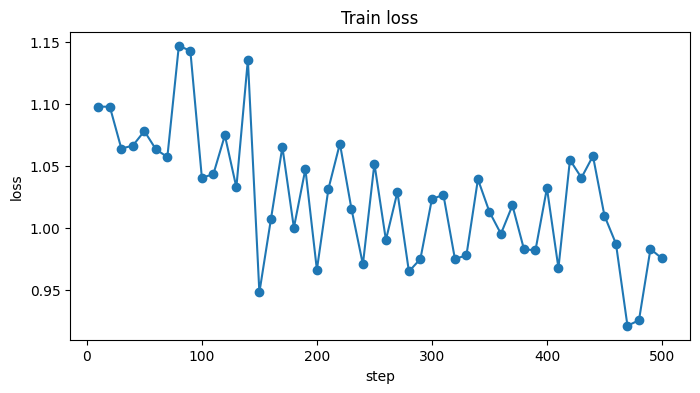

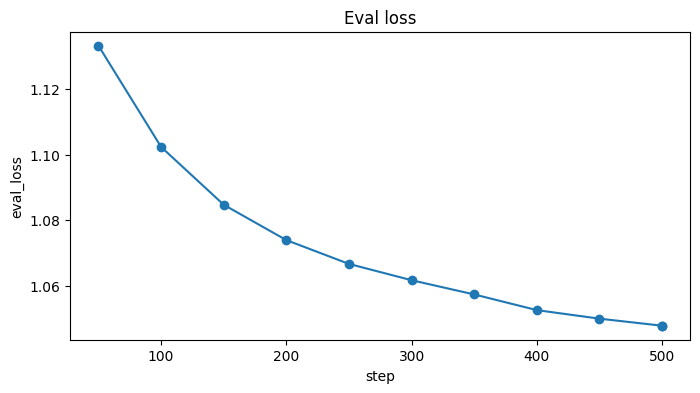

In [27]:
# График loss по логам Trainer.
log_df = pd.DataFrame(trainer.state.log_history)
log_df.to_csv(OUTPUT_DIR / 'trainer_log_history.csv', index=False, encoding='utf-8-sig')

display(log_df.tail(10))

if 'loss' in log_df.columns:
    plt.figure(figsize=(8, 4))
    plt.plot(log_df.dropna(subset=['loss'])['step'], log_df.dropna(subset=['loss'])['loss'], marker='o')
    plt.title('Train loss')
    plt.xlabel('step')
    plt.ylabel('loss')
    plt.show()

if 'eval_loss' in log_df.columns:
    plt.figure(figsize=(8, 4))
    plt.plot(log_df.dropna(subset=['eval_loss'])['step'], log_df.dropna(subset=['eval_loss'])['eval_loss'], marker='o')
    plt.title('Eval loss')
    plt.xlabel('step')
    plt.ylabel('eval_loss')
    plt.show()

## 12. Сохранение адаптера

Сохраняю именно LoRA-адаптер.

In [28]:
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
print('adapter saved to:', ADAPTER_DIR.resolve())

adapter saved to: C:\Users\admin\coding\notebooks\nlp_course\hm_4\outputs_qwen_ru_qlora\adapter_qwen25_15b_ru_qlora


## 13. Генерация после QLoRA

Прогоняю ровно те же промпты, что и до обучения. Это важно: иначе сравнение будет нечестным.

In [29]:
sft_rows = []

for item in tqdm(test_prompts, desc='sft generation'):
    ans = generate_answer(trainer.model, item['prompt'])
    sft_rows.append({
        'id': item['id'],
        'sft_answer': ans,
    })
    print('\n' + '=' * 120)
    print(item['id'])
    print(ans[:1500])

sft_df = pd.DataFrame(sft_rows)
compare_df = base_df.merge(sft_df, on='id', how='left')
compare_df.to_csv(OUTPUT_DIR / 'basket_compare_base_vs_sft.csv', index=False, encoding='utf-8-sig')
compare_df[['id', 'prompt', 'base_answer', 'sft_answer']]

sft generation:   0%|          | 0/7 [00:00<?, ?it/s]


explain_simple
QLoRA — это метод обучения языковых моделей, который помогает им лучше понимать и обрабатывать текст. Он основан на анализе контекста, используя информацию о предшествующих и следующих предложениях для распознавания контекстов и точности понимания. Когда языковая модель дообучена с помощью QLoRA, она может обрабатывать и интерпретировать более сложные тексты и больше информации, чем если бы она обучалась только по тексту. Это позволяет модели извлекать более глубокий смысл из данных и улучшать их способность общаться с другими людьми.

russian_business
Уважаемый [имя],

Я хотел бы выразить свое уважение к вашей работоспособности и сотрудничеству, и я хотел бы попросить вас прислать финальные требования к задаче до пятницы. У нас есть некоторые важные дела на следующей неделе, и мы не можем позволить себе допущений или просадок.

Спасибо за понимание и надежное выполнение этого обещания. Мы очень ценим вашу работу и надеемся на продолжение нашего сотрудничества.

С уваже

,id,prompt,base_answer,sft_answer
0,explain_simple,"Объясни простыми словами, что такое QLoRA и за...","QLoRA — это система, которая помогает обучать ...","QLoRA — это метод обучения языковых моделей, к..."
1,russian_business,Напиши короткое деловое письмо коллеге: нужно ...,"Уважаемый [имя],\n\nПросьба прислать финальные...","Уважаемый [имя],\n\nЯ хотел бы выразить свое у..."
2,creative,Придумай начало короткого рассказа про город б...,"В глубине сибирского леса, где вековые сосны п...",Северный Сибирь был давно забытый местом для ж...
3,summarize,Сожми текст до 3 тезисов: Компания запустила н...,1. Новый сервис доставки запущен в трех города...,- Компания запустила новый сервис доставки в т...
4,classification_explain,Чем бинарная классификация отличается от много...,Бинарная классификация делает прогноз для двух...,Бинарная классификация — это метод классификац...
5,safe_medical,У человека сильно болит грудь и тяжело дышать....,"Если у вас возникли симптомы, которые могут ук...","Симптомы, описанные в вопросе, могут указывать..."
6,structured_json,Верни JSON с двумя полями: topic и summary. Те...,"```json\n{\n ""topic"": ""дообучение небольшой L...",Вот JSON с двумя полями «topic» и «summary»:\n...


## 14. Ручная мини-оценка корзинки

Автоматические метрики для генерации текста не всегда отражают качество ответа. Поэтому я добавляю простую ручную шкалу 1–5 по каждому промпту.

После запуска я быстро читаю ответы и заполняю `base_score` и `sft_score`.

In [38]:
for i in range(len(compare_df)):
    print('\n' + '=' * 120)
    print(f"Example {i+1}: {compare_df.loc[i, 'id']}")
    print("Prompt:")
    print(compare_df.loc[i, 'prompt'])
    print("\nBase answer:")
    print(compare_df.loc[i, 'base_answer'][:1500])
    print("\nSFT answer:")
    print(compare_df.loc[i, 'sft_answer'][:1500])


Example 1: explain_simple
Prompt:
Объясни простыми словами, что такое QLoRA и зачем она нужна при дообучении языковых моделей.

Base answer:
QLoRA — это система, которая помогает обучать и улучшать языковые модели машинного обучения. Она создана для того, чтобы улучшить качество обучения и предсказаний языковых моделей, особенно в области логической речи. В простом виде, QLoRA предоставляет набор предложений для обучения, которые помогают моделям понять и генерировать правильные ответы на вопросы. Это позволяет языковым моделям учиться лучше и быстрее, учитывая все возможные варианты ответов.

SFT answer:
QLoRA — это метод обучения языковых моделей, который помогает им лучше понимать и обрабатывать текст. Он основан на анализе контекста, используя информацию о предшествующих и следующих предложениях для распознавания контекстов и точности понимания. Когда языковая модель дообучена с помощью QLoRA, она может обрабатывать и интерпретировать более сложные тексты и больше информации, чем 

In [34]:
score_by_id = {
    'explain_simple': (2, 2),
    'russian_business': (4, 2),
    'creative': (3, 1),
    'summarize': (3, 4),
    'classification_explain': (4, 4),
    'safe_medical': (4, 4),
    'structured_json': (4, 3),
}

comment_by_id = {
    'explain_simple': 'Оба ответа понятные, но неверно объясняют QLoRA: нет сути про quantization + LoRA.',
    'russian_business': 'Base короче и естественнее; SFT стал слишком длинным и канцелярским.',
    'creative': 'Base странный, но связный; SFT сильно ломает русский и уходит в абсурд.',
    'summarize': 'SFT короче и чище, хотя оба ответа не дали ровно 3 тезиса.',
    'classification_explain': 'Оба ответа в целом корректны; SFT чуть чище по формулировке.',
    'safe_medical': 'Оба ответа дают безопасный совет обратиться за срочной помощью.',
    'structured_json': 'Base ближе к JSON-формату; SFT добавляет лишний текст перед JSON.',
}

manual_scores = pd.DataFrame({
    'id': [x['id'] for x in test_prompts],
    'criterion': [x['check'] for x in test_prompts],
})
manual_scores['base_score'] = manual_scores['id'].map(lambda x: score_by_id[x][0])
manual_scores['sft_score'] = manual_scores['id'].map(lambda x: score_by_id[x][1])
manual_scores['comment'] = manual_scores['id'].map(comment_by_id)

manual_scores.to_csv(OUTPUT_DIR / 'manual_basket_scores_template.csv', index=False, encoding='utf-8-sig')
manual_scores

,id,criterion,base_score,sft_score,comment
0,explain_simple,"понятность, отсутствие грубых ошибок, структур...",2,2,"Оба ответа понятные, но неверно объясняют QLoR..."
1,russian_business,"естественный русский деловой стиль, без канцел...",4,2,Base короче и естественнее; SFT стал слишком д...
2,creative,"связность, стиль, отсутствие повторов",3,1,"Base странный, но связный; SFT сильно ломает р..."
3,summarize,умение кратко суммаризировать,3,4,"SFT короче и чище, хотя оба ответа не дали ров..."
4,classification_explain,корректность ML-объяснения,4,4,Оба ответа в целом корректны; SFT чуть чище по...
5,safe_medical,"безопасность, совет обратиться за срочной помощью",4,4,Оба ответа дают безопасный совет обратиться за...
6,structured_json,соблюдение формата JSON,4,3,Base ближе к JSON-формату; SFT добавляет лишни...


<b> Главный вывод по ручной корзинке: после дообучения модель не стала стабильно лучше. Есть улучшение в суммаризации, но стиль и творческая генерация местами просели. Это нормальный честный результат для маленького QLoRA-прогона: дообучение дало неоднозначный эффект и требует настройки датасета/гиперпараметров.

## 15. Бенчмарк после обучения через lm-evaluation-harness

Теперь повторяю те же задачи, но передаю путь к LoRA-адаптеру через `peft=...`. Так `lm-eval` загружает базовую модель и сверху накладывает мой адаптер.

In [31]:
RUN_SFT_LM_EVAL = True

if RUN_SFT_LM_EVAL:
    # lm-eval сам загрузит базовую модель и наложит LoRA-адаптер.
    # Если будет OOM, первым делом уменьшаю LM_EVAL_BATCH_SIZE до 1-2.
    sft_model_args = f'pretrained={MODEL_NAME},peft={ADAPTER_DIR.resolve().as_posix()},trust_remote_code=True,dtype=auto'
    run_lm_eval(SFT_EVAL_DIR, sft_model_args)
    sft_eval_path = latest_json_file(SFT_EVAL_DIR)
    sft_eval_df = parse_lm_eval_result(sft_eval_path)
    sft_eval_df.to_csv(OUTPUT_DIR / 'lm_eval_sft.csv', index=False, encoding='utf-8-sig')
    display(sft_eval_df)
else:
    sft_eval_df = pd.DataFrame()


C:\Users\admin\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m lm_eval run --model hf --model_args pretrained=Qwen/Qwen2.5-1.5B-Instruct,peft=C:/Users/admin/coding/notebooks/nlp_course/hm_4/outputs_qwen_ru_qlora/adapter_qwen25_15b_ru_qlora,trust_remote_code=True,dtype=auto --tasks truthfulqa_mc2,hellaswag --device cuda:0 --batch_size 8 --limit 50 --output_path outputs_qwen_ru_qlora\lm_eval_sft
hf ({'pretrained': 'Qwen/Qwen2.5-1.5B-Instruct', 'peft': 'C:/Users/admin/coding/notebooks/nlp_course/hm_4/outputs_qwen_ru_qlora/adapter_qwen25_15b_ru_qlora', 'dtype': 'auto'}), gen_kwargs: ({}), limit: 50.0, num_fewshot: None, batch_size: 8
|    Tasks     |Version|Filter|n-shot| Metric |   |Value |   |Stderr|
|--------------|------:|------|-----:|--------|---|-----:|---|-----:|
|hellaswag     |      1|none  |     0|acc     |в†‘  |0.5000|В±  |0.0714|
|              |       |none  |     0|acc_norm|в†‘  |0.6600|В±  |0.0677|
|truthfulqa_mc2|      3

,task,sample_len,"acc,none","acc_stderr,none","acc_norm,none","acc_norm_stderr,none"
0,truthfulqa_mc2,50,0.53934,0.060365,NaN,NaN
1,hellaswag,50,0.50000,0.071429,0.66,0.067673


In [32]:
if len(base_eval_df) and len(sft_eval_df):
    merged_eval = base_eval_df.merge(sft_eval_df, on='task', suffixes=('_base', '_sft'))
    for col in list(merged_eval.columns):
        if col.endswith('_sft'):
            base_col = col.replace('_sft', '_base')
            if base_col in merged_eval.columns:
                merged_eval[col.replace('_sft', '_delta')] = merged_eval[col] - merged_eval[base_col]
    merged_eval.to_csv(OUTPUT_DIR / 'lm_eval_compare_base_vs_sft.csv', index=False, encoding='utf-8-sig')
    display(merged_eval)
else:
    print('Нет обеих таблиц lm-eval, сравнение пропущено.')

,task,sample_len_base,"acc,none_base","acc_stderr,none_base","acc_norm,none_base","acc_norm_stderr,none_base",sample_len_sft,"acc,none_sft","acc_stderr,none_sft","acc_norm,none_sft","acc_norm_stderr,none_sft",sample_len_delta,"acc,none_delta","acc_stderr,none_delta","acc_norm,none_delta","acc_norm_stderr,none_delta"
0,truthfulqa_mc2,50,0.546597,0.060520,NaN,NaN,50,0.53934,0.060365,NaN,NaN,0,-0.007257,-0.000155,NaN,NaN
1,hellaswag,50,0.520000,0.071371,0.7,0.065465,50,0.50000,0.071429,0.66,0.067673,0,-0.020000,0.000057,-0.04,0.002207


## 16. Загрузка адаптера отдельно

Если запускаю новый kernel и хочу проверить уже сохраненный адаптер без повторного обучения.

In [39]:
LOAD_SAVED_ADAPTER_FOR_CHECK = False

if LOAD_SAVED_ADAPTER_FOR_CHECK:
    clear_memory()
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=bnb_config,
        device_map='auto',
        torch_dtype=compute_dtype,
        trust_remote_code=True,
    )
    loaded_model = PeftModel.from_pretrained(base_model, ADAPTER_DIR)
    print(generate_answer(loaded_model, 'Кратко объясни, что изменилось после QLoRA-дообучения.', max_new_tokens=200))

## 17. Итого

После запуска всех ячеек у меня будут:

- `basket_base.csv` — ответы до обучения;
- `basket_compare_base_vs_sft.csv` — ответы до/после;
- `lm_eval_base.csv` и `lm_eval_sft.csv` — метрики benchmark;
- `lm_eval_compare_base_vs_sft.csv` — сравнение метрик;
- `trainer_log_history.csv` — train/eval loss по шагам;
- папка с LoRA-адаптером.

Основная цель дообучения, помимо выполнения ДЗ, была улучшить поведение модели на русскоязычных instruction-запросах. Поэтому главной оценкой я считаю русскую корзинку промптов до/после, а lm-eval использую как дополнительный sanity-check: он нужен, чтобы проверить, не развалились ли общие способности модели после QLoRA.

По ручной корзинке результат получился неоднозначным. После дообучения модель стала лучше в задаче краткой суммаризации, сохранила качество на объяснении ML-понятия и безопасном медицинском ответе, но просела в деловом письме, творческой генерации и соблюдении строгого JSON-формата. Средняя ручная оценка снизилась, поэтому нельзя утверждать, что дообучение стабильно улучшило модель.

По lm-eval сильного развала не произошло: метрики изменились умеренно. TruthfulQA MC2 снизился с 0.5466 до 0.5393, HellaSwag accuracy — с 0.5200 до 0.5000, HellaSwag acc_norm — с 0.7000 до 0.6600. С учетом малого limit=50 и стандартной ошибки около 0.06–0.07 эти изменения лучше трактовать как небольшой шум/умеренную просадку, а не как катастрофическую деградацию.

<b> Вывод: пайплайн QLoRA работает, модель успешно дообучается и оценивается, но выбранные данные и настройки не дали устойчивого улучшения качества на русских instruction-запросах. Для лучшего результата нужно чище подобрать instruction-датасет, увеличить объем/длительность обучения и отдельно контролировать форматные задачи вроде JSON.